# RLC Network Response - Compare Impulse and Step Responses

In [1]:
from pathlib import Path
import sys, csv

COURSEUTILS_DIR = Path.home() / "Documents/GitHub/Signals_and_Systems/courseutils"
sys.path.insert(0, str(COURSEUTILS_DIR))

import basic_material as bm
bm.setup_environment()

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from lcapy import Circuit, j, omega, s, exp, delta, t
from lcapy import R, C, L, symbol

from IPython.display import display, Javascript
display(Javascript('document.title = "RC and RL Networks Response";'))

import warnings
warnings.filterwarnings(
    "ignore",
    message="divide by zero encountered in divide"
)
warnings.filterwarnings(
    "ignore",
    message="invalid value encountered in divide"
)

/Users/jonathanhow/Jon/venv312/lib/python3.12/site-packages/lcapy/__init__.py:76: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


<IPython.core.display.Javascript object>

## Consider impulse response of the RLC network

For a short 1 V pulse of width $\Delta T$, the impulse approximation replaces the pulse by an impulse with the same area, $\Delta T\delta(t)$.

$$
\int_0^{\Delta T} 1\,dt = \Delta T.
$$

As $\Delta T \to 0$, this pulse approaches $\Delta T\delta(t)$ in the impulse approximation. Thus, if we use a 1 V pulse of width $\Delta T=10^{-4}$ s, the corresponding impulse input is

$$
v_{in}(t)=10^{-4}\delta(t).
$$

So `scale = 1e-4` is the impulse area in V-s.

Impulse input


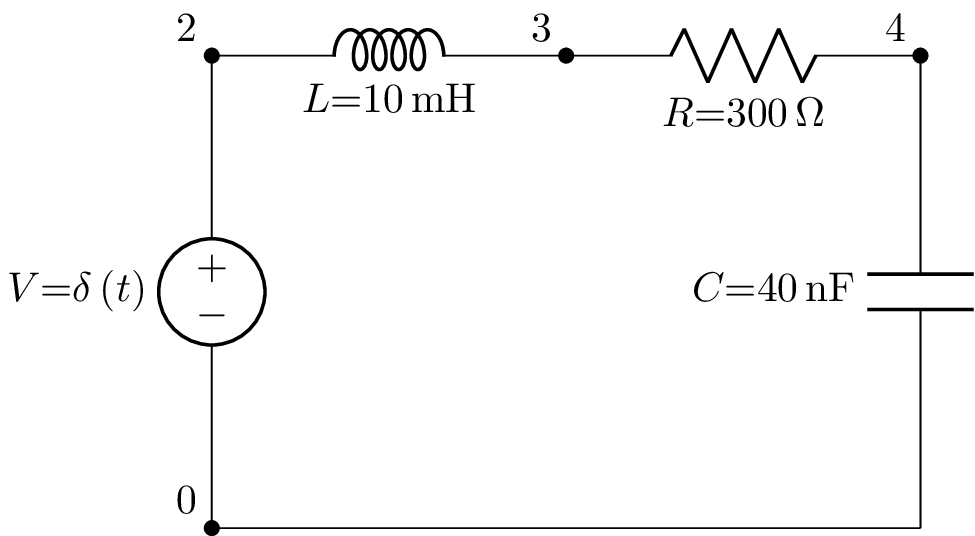

In [3]:
RR = 300 # resistor
CC = 40e-9 # capacitor value
LL = 10e-3 # inductor value
DeltaT = 1e-4  # 0.1 ms pulse width
scale = DeltaT # area of a 1 V rectangular pulse, so u(t)-u(t-DeltaT) -> DeltaT*delta(t)

cct7 = Circuit(f"""
V 2 0 {{delta(t)}}; down=2
L 2 3 {LL} 0; right=1.5
R 3 4 {RR}; right=1.5
C 4 0_4 {CC} 0; down=1.5
W 0 0_4; right
""")

cct7a = cct7.subs({'R': RR, 'C':CC, 'L':LL})
print("Impulse input")
cct7a.draw()

Step input


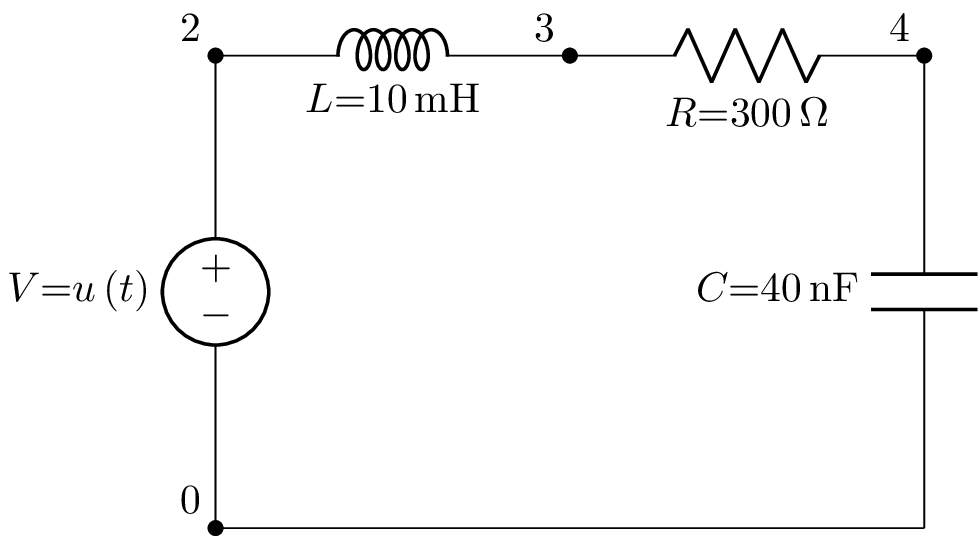

In [4]:
cct8 = Circuit(f"""
V 2 0 {{u(t)}}; down=2
L 2 3 {LL} 0; right=1.5
R 3 4 {RR}; right=1.5
C 4 0_4 {CC} 0; down=1.5
W 0 0_4; right
""")

cct8a = cct8.subs({'R': RR, 'C':CC, 'L':LL})
print("Step input")
cct8a.draw()

In [5]:
# Define variables that govern the system response

# Natural Freq
wn = 1/np.sqrt(LL*CC)
# Damping value
zeta = RR/LL/2/wn
# Damped Freq
wd = wn*np.sqrt(1-zeta**2)

print(f"\tFrequency \t= {wn:.1f} rad/sec")
print(f"\tDamped Freq \t= {wd:.1f} rad/sec")
print(f"\tDamping ratio \t= {(zeta):.2f}")
print(f"\tReal part \t= {(-zeta*wn):.1f}") 

	Frequency 	= 50000.0 rad/sec
	Damped Freq 	= 47697.0 rad/sec
	Damping ratio 	= 0.30
	Real part 	= -15000.0


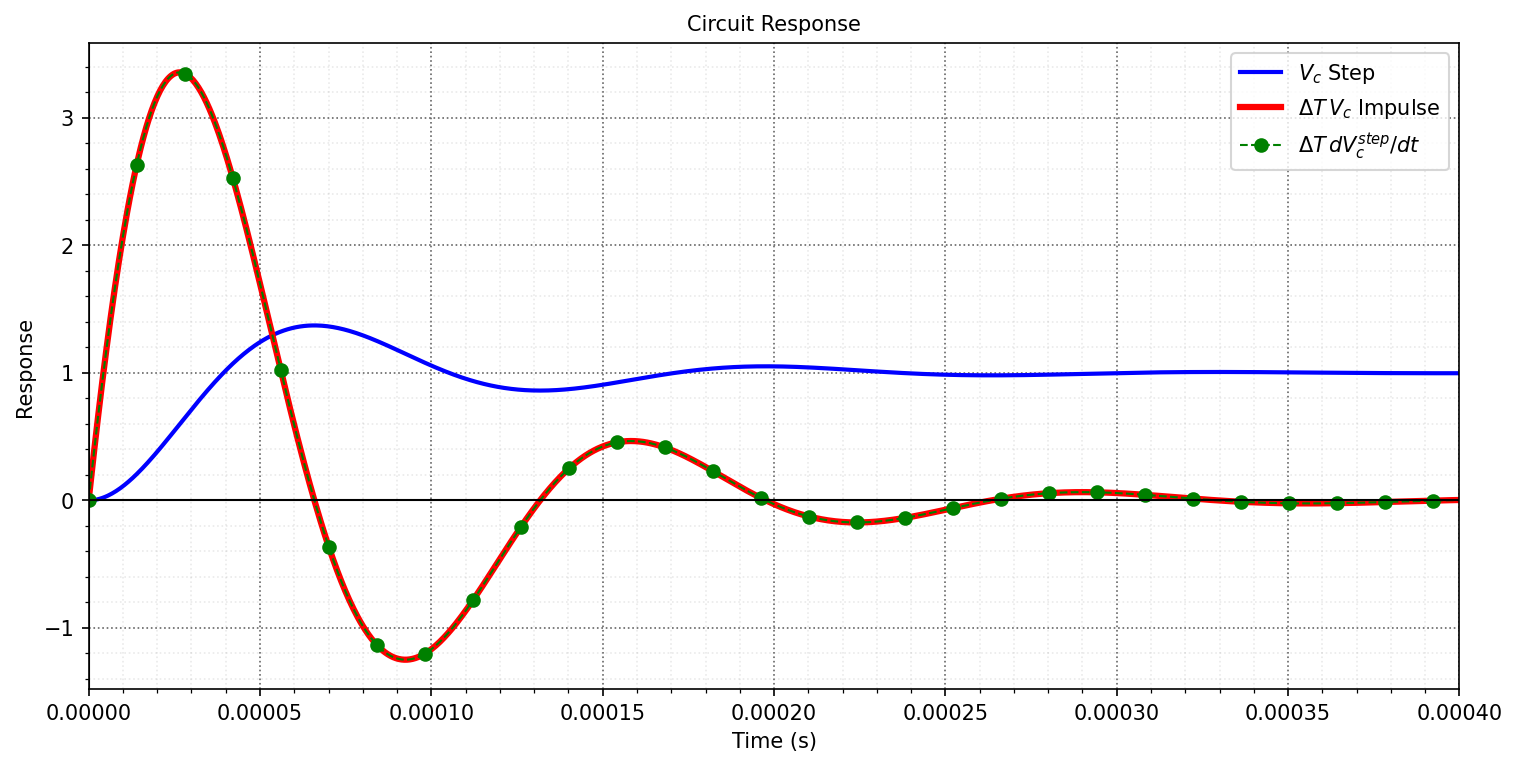

Plot numerically confirms that the derivative of the step response is the same as the impulse response


In [6]:
# Compute time response
tt = np.linspace(1e-12, np.round(20/wd,4), 1000)
vc_impulse = cct7a.C.v.evaluate(tt) # capacitor voltage
vc_step = cct8a.C.v.evaluate(tt) # capacitor voltage
vc_step_diff = cct8a.C.v.differentiate(t)

fig = plt.figure(figsize=(10, 5),dpi=150,constrained_layout = True)
ax = fig.add_subplot(111, title='Circuit Response')
ax.plot(tt, vc_step, linewidth=2, color='blue', label='$V_c$ Step')
ax.plot(tt, scale*vc_impulse, linewidth=3, color='red', label='$\Delta T\, V_c$ Impulse')
ax.plot(tt, scale*vc_step_diff.evaluate(tt), 'go--', linewidth=1, label=r'$\Delta T\, dV_c^{step}/dt$',markevery=35)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Response');
bm.nicegrid(ax)
plt.legend()
plt.show()

txt = 'Plot numerically confirms that the derivative of the step response is the same as the impulse response'
print(txt)